In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

input_file = "dataSet.csv"
output_file = "dataSet_fixed.csv"

<table>
  <tr>
    <th>Column Name	</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Serial Number</td>
    <td>A unique identifier for each record in the dataset.</td>
  </tr>
  <tr>
    <td>List Year</td>
    <td>The grand list year in which the sale was recorded.</td>
  </tr> 
  <tr>
    <td>Date Recorded</td>
    <td>The date when the sale was recorded.</td>
  </tr>    
  <tr>
    <td>Town</td>
    <td>The town where the property is located.</td>
  </tr>  
  <tr>
    <td>Address</td>
    <td>The address of the property.</td>
  </tr>   
  <tr>
    <td>Assessed Value</td>
    <td>The assessed value of the property.</td>
  </tr>       
  <tr>
    <td>Sale Amount</td>
    <td>The sales price of the property.</td>
  </tr>    
  <tr>
    <td>Sales Ratio	</td>
    <td>The sales ratio of the property.</td>
  </tr>    
  <tr>
    <td>Property Type	</td>
    <td>The type of the property (residential, apartment, commercial, industrial, or vacant land).</td>
  </tr>
  <tr>
    <td>Residential Type	</td>
    <td>The type of residential property (if applicable).</td>
  </tr>    
  <tr>
    <td>Non Use Code	</td>
    <td>The non-use code associated with the property (if applicable).</td>
  </tr>     
  <tr>
    <td>Assessor Remarks	</td>
    <td>Remarks or comments provided by the assessor (if available).</td>
  </tr>  
  <tr>
    <td>OPM Remarks	</td>
    <td>Remarks or comments provided by the Office of Policy and Management (if available).</td>
  </tr>   
  <tr>
    <td>Location</td>
    <td>The location of the property (if available).</td>
  </tr>      
</table>


<h4>Leyendo el archivo parece que tenemos 2 tipos de separadores "," y ";" sin embargo hay una 
 seccion que sale como "," por lo que decidi reemplazar todos los ";" a "," para poder leer esas comas 
 como si fueran columnas y asi eliminarlas por ende este codigo procede a 
 reemplazar todas los semicolons por comas</h4>

In [2]:
with open(input_file, "r", encoding="utf-8") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        fixed_line = line.replace(";", ",")
        outfile.write(fixed_line)

In [3]:
df = pd.read_csv(output_file, sep=",",  on_bad_lines="skip",  low_memory=False)

<h4>Hay un total de 190016 filas y 287 columnas</h4>

In [4]:
cols_valida = []
cols_invalida = []
for col in df.columns:
    if "unnamed" in col.lower():
        cols_invalida.append(col)
    else:
        cols_valida.append(col)

<h4>Al leer el csv reemplazado habran muchas columnas sin valores por ende procedemos a remover todas las columnas adicionales dejando solo 14 columnas</h4>

In [5]:
# df.drop(df.iloc[:, 14:287], inplace=True, axis=1)
for col in cols_invalida:
    df = df.drop(col, axis=1)


In [6]:
cols_num = [
    'Serial Number',
    'List Year'
]

cols_float = [
    'Assessed Value',
    'Sale Amount',
    'Sales Ratio'
]

<h4>
Revisando los datos hay columnas que tienen datos erroneos, por ejemplo hay columnas que deberian de contener datos solo numericos pero por a la hora de ingresarlas ingresaron otro tipo de datos, para ello procedemos a identificar las columnas que deberian de ser numeros y si encontramos una que no es asi procedemos a dropear la fila
</h4>

In [7]:
for col in [*cols_num, *cols_float]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=[col])

<h4>Al final quedan 189933 filas que si son validas, ahora procedemos a cambiar los datos a su tipo</h4>

In [8]:
for col in cols_num:
    df[col] = df[col].astype('int')
    
for col in cols_float:
    df[col] = df[col].astype('float')    

df['Date Recorded'] = pd.to_datetime(df['Date Recorded'])    

In [9]:
df.loc[df['Property Type'].str.contains(r',{2,}', na=False), 'Property Type'] = np.nan

<h4>El date recorded tiene el la fecha de venta, por ende creamos una columna llamada sell year que solo va a tener el año  de venta</h4>

In [10]:
df['Sell Year'] = df['Date Recorded'].dt.year
df['Sell Year'] = df['Sell Year'].astype('Int64')

In [11]:
#Ingreso anual
#¿Cuál es el ingreso anual de las propiedades vendidas?
result_df = df.groupby('Sell Year')['Sale Amount'].sum().reset_index()

<h4>Para crear el grafico de ventas anuales como son numeros grandes estamos haciendo una division de totales para despues representarlos en billones</h4>

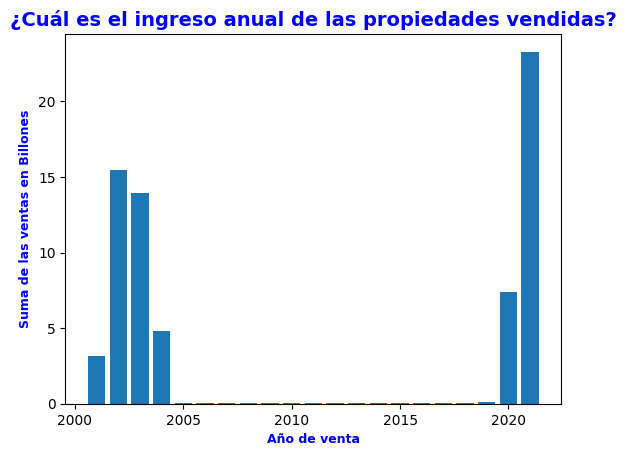

In [12]:
x = result_df["Sell Year"]
y = result_df["Sale Amount"]
y = [ (val/1000000000) for val in y]
fig, ax = plt.subplots()
ax.set_title("¿Cuál es el ingreso anual de las propiedades vendidas?", fontsize=14, fontweight='bold', color='blue')
ax.set_ylabel("Suma de las ventas en Billones", fontsize=9, fontweight='bold', color='blue')
ax.set_xlabel("Año de venta", fontsize=9, fontweight='bold', color='blue')
ax.bar(x = x, height = y)
plt.show()

<h4>¿Qué tipo de propiedad tiene mayor facilidad de venta?</h4>

In [13]:
conteo_tipo_propiedades = df['Property Type'].value_counts()
print(conteo_tipo_propiedades)

Property Type
Residential       51271
Vacant Land        2621
Commercial         1713
Apartments          402
Condo               370
Industrial          196
Public Utility        4
Two Family            2
Single Family         2
Three Family          1
Name: count, dtype: int64


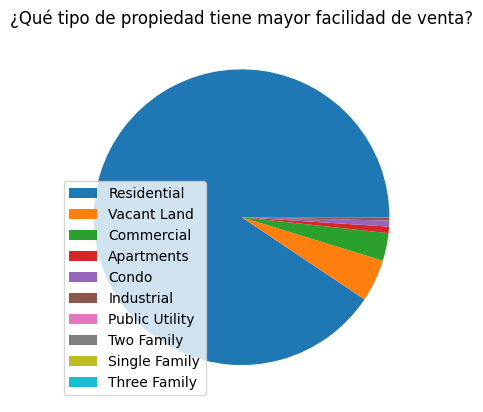

In [14]:
conteo_tipo_propiedades.plot.pie(labels=None,legend=True)
plt.ylabel('')  # Remove the y-label (optional)
plt.title('¿Qué tipo de propiedad tiene mayor facilidad de venta?')
plt.show()

<h4>¿En cuál ciudad o pueblo se dan mayor cantidad de ventas de propiedades? Como son tantos solo queremos mostrar el top 10</h4>

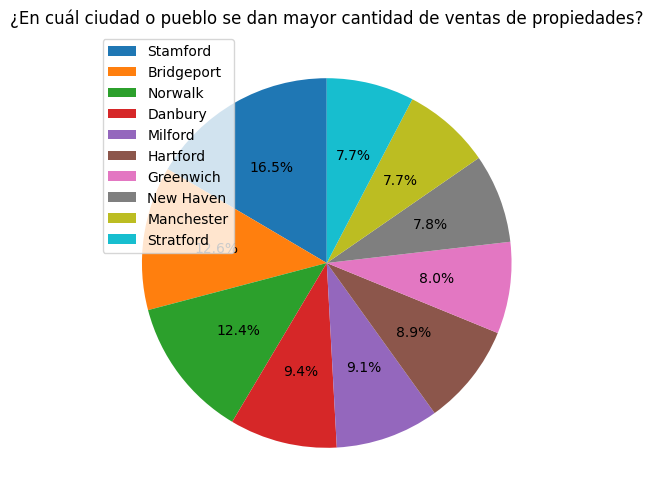

In [15]:
conteo_pueblo = df['Town'].value_counts().head(10)
conteo_pueblo.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6,6), labels=None,legend=True)
plt.ylabel('')  # Remove the y-label (optional)
plt.title('¿En cuál ciudad o pueblo se dan mayor cantidad de ventas de propiedades?')
plt.show()

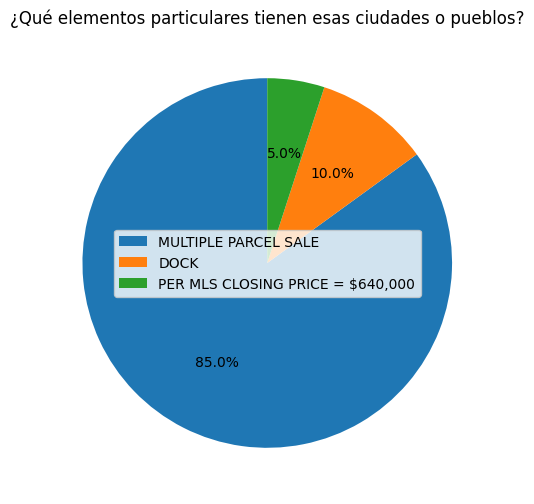

In [44]:
# ¿Qué elementos particulares tienen esas ciudades o pueblos?
# filtered_df = df[df['Town'] == "Stamford"]
# filtered_df.head(10)
#filtered_df = df.groupby('Town')['Sales Ratio'].agg(['mean'])
# filtered_df = df.groupby('Town')['Sales Ratio'].mean().sort_values(ascending=False)
# print(filtered_df)

filtrar_por_pueblo = df[df['Town'] == "Stamford"]
particularidades = filtrar_por_pueblo["OPM remarks"].value_counts().head(3)
particularidades.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6,6), labels=None,legend=True)
plt.ylabel('')  # Remove the y-label (optional)
plt.title('¿Qué elementos particulares tienen esas ciudades o pueblos?')
plt.show()


In [17]:
# max_val = filtered_df['Sale Amount'].max()
# print(max_val)

In [18]:
# min_val = filtered_df['Sale Amount'].min()
# print(min_val)

In [19]:
# foo_df = filtered_df[filtered_df['Sale Amount'] == 10]

# foo_df.head(1)

In [20]:
# comercial_df = df[df["Property Type"] == "Commercial"]
# residencial_df = df[df["Property Type"] == "Residential"]

In [21]:
# #¿Cuál es el costo promedio de las propiedades residenciales y comerciales?
# print("El promedio comercial", comercial_df["Sale Amount"].mean())
# print("El promedio residencial", residencial_df["Sale Amount"].mean())

In [22]:
# #. ¿Cuál es tipo de propiedades residenciales que se vende con mayor frecuencia, donde y con que costo promedio?
# conteo_tipo_residenciales = df['Residential Type'].value_counts().head(1)
# print(conteo_tipo_residenciales)

In [23]:
# filtrado_tipo_residencial_df = df[df['Residential Type'] == "Single Family"]

In [24]:
# #donde
# print(filtrado_tipo_residencial_df['Town'].value_counts().head(1))